In [98]:
# # Install zstd first
# !apt-get update -qq
# !apt-get install -y zstd

# # Install Ollama
# !curl -fsSL https://ollama.com/install.sh | sh

# # Start Ollama server in the background
# import subprocess
# import time

# subprocess.Popen(["ollama", "serve"])
# time.sleep(5)

# # Pull the DeepSeek-R1 7B model
# !ollama pull deepseek-r1:7b

# print("✅ Ollama setup complete!")

In [99]:
from __future__ import annotations
from pydantic import BaseModel, Field
from typing import Annotated, List, TypedDict
from langchain_core.messages import SystemMessage, HumanMessage

# !pip install langchain_ollama
from langchain_ollama import ChatOllama

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
import operator

In [100]:
#@ Pydantic Functions:

#Task:
class Task(BaseModel):
    id: int
    title: str
    brief: str= Field(..., description='What to look for')

#planner:
class Plan(BaseModel):
    blog_title:str
    tasks:List[Task]

#state:
class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str], operator.add] #esults from workers get automatically concatenated
    final: str


In [101]:
llm=ChatOllama(model="deepseek-r1:7b")

In [102]:
#@ Orchestrator(Planner):
def orchestator(state:State)->dict:
    plan=llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=("Create a blog plan on 5-7 on the following topic")
            ),

            HumanMessage(content=f"Topic:{state['topic']}")
        ]
    )

    return {'plan': plan}

- After the orchestrator node, system doesnt know how many workers do it need wrt to plan, so we need to built a fucntion which will trigger a worker for each plan/section

In [103]:
def trigger(state: State):
    return [Send("worker", {'task': task, 'topic': state['topic'], 'plan': state['plan']} )for task in state['plan'].tasks]


In [104]:
#@ worker node:
def worker(payload:dict):

    #payoad contains what we send
    task=payload['task']
    topic=payload['topic']
    plan=payload['plan']

    blog_topic=plan.blog_title

    section_md=llm.invoke(
        [
        SystemMessage(content="Write one clear markdown section"),
        HumanMessage(
            content=(
                f"Blog: {blog_topic}\n",
                f"topic: {topic}\n",
                f"section: {task.title}\n",
                f"brief: {task.brief}\n\n"
            )
        )]
    ).content.strip()

    return {"sections": [section_md]}

In [110]:
from pathlib import Path

#@ Creating a reducer function:
def reducer(state:State):
    title=state['plan'].blog_title
    body= "\n\n".join(state['sections']).strip()

    final_md=f'# {title} \n\n {body}\n'


    #@ Saving md files:
    filename=title.lower().replace('' ,'_') + ".md"
    output_path=Path(filename)
    output_path.write_text(final_md, encoding='utf-8')

    return {"final": final_md}

In [111]:
g=StateGraph(State)
g.add_node("orchestator", orchestator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

In [112]:
g.add_edge(START, "orchestator")
g.add_conditional_edges("orchestator", trigger, ['worker'])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

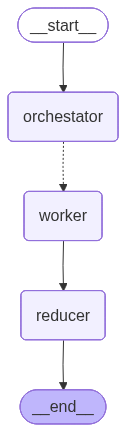

In [113]:
app=g.compile()
app

In [114]:
result=app.invoke({"topic": "write a blog on mountains", "sections":[]})
result

{'topic': 'write a blog on mountains',
 'plan': Plan(blog_title='The Beauty of Mountains', tasks=[Task(id=1, title='Introduction: Exploring the World of Mountains', brief="Welcome to our journey through the diverse and majestic world of mountains. In this series, we'll explore their beauty, history, culture, and significance."), Task(id=2, title='Types of Mountains: A Comprehensive Guide', brief='Discover the different types of mountains around the globe, including oceanic, alpine, volcanic, and more. Understand their unique characteristics and formation processes.'), Task(id=3, title='The Andes: A Mountain Range to Remember', brief="Dive deep into one of the world's most significant mountain ranges—the Andes. Learn about its history, culture, and natural wonders."), Task(id=4, title='Mount Fuji: The Iconic Japanese Landscape', brief='Explore the iconic Mount Fuji, known as the Golden Bell. Discover its geology, history, and cultural significance in Japan.'), Task(id=5, title='Mountain